# Notebook 2 — Churn Prediction (XGBoost)

**Goal**: Train a binary classifier to predict whether a customer will churn.
**Prerequisite:** Notebook 1 (EDA) must have been run and data must be in PostgreSQL.

---

### Steps in this notebook

1. Build feature matrix from PostgreSQL
2. Visualise feature distributions (churned vs active)
3. Show RFM segment breakdown
4. Train XGBoost model (via `src\train_churn.py`)
5. Inspect SHAP feature importance
6. Verify predictions written to PostgreSQL


In [1]:
import sys
sys.path.append('../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.features import build_feature_matrix, get_rfm_segments, FEATURE_COLS, CHURN_TARGET
from src.db import engine

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK.')

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Imports OK.


## Step 1 — Build feature matrix

In [2]:
df = build_feature_matrix()
df = get_rfm_segments(df)

print(f'Shape     : {df.shape}')
print(f'Churn rate: {df[CHURN_TARGET].mean():.1%}')
print(f'\nSample rows:')
df[FEATURE_COLS + [CHURN_TARGET, 'rfm_segment']].head(3)

Pulling RFM features ...
Pulling review features ...
Pulling category features ...
Feature matrix: 93,357 customers | churn rate 24.9%
Shape     : (93357, 21)
Churn rate: 24.9%

Sample rows:


,recency_days,frequency,monetary,avg_order_value,max_order_value,min_order_value,std_order_value,review_count,avg_review_score,unique_categories,customer_age_days,orders_per_month,revenue_per_day,churned,rfm_segment
0,2891.0,1,141.90,141.90,141.90,141.90,0.0,1,5.0,1,0,1.0,141.90,0,Recent Customers
1,2894.0,1,27.19,27.19,27.19,27.19,0.0,1,4.0,1,0,1.0,27.19,0,Recent Customers
2,3316.0,1,86.22,86.22,86.22,86.22,0.0,1,3.0,1,0,1.0,86.22,1,Lost


## Step 2 — Feature distributions: Active vs Churned


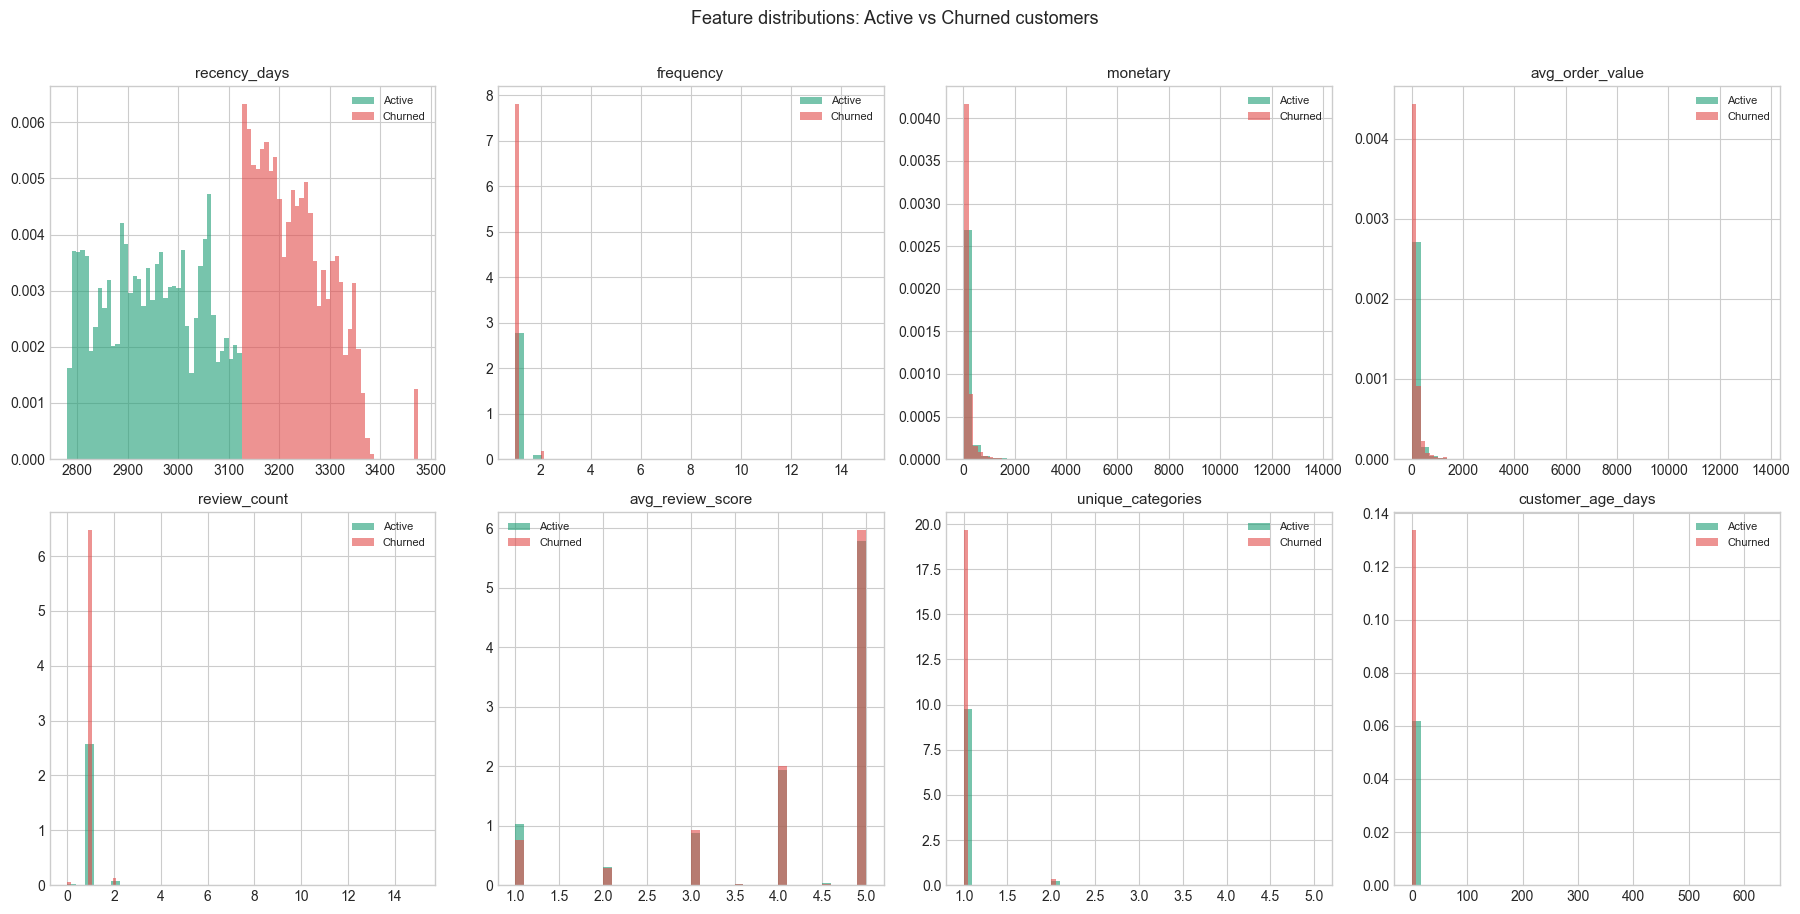

In [3]:
import os
os.chdir(r"C:\Users\dell\OneDrive\Desktop\ecommerce_intelligence\notebooks\02_churn")

key_features = ['recency_days','frequency','monetary','avg_order_value',
                'review_count','avg_review_score','unique_categories','customer_age_days']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_features):
    active  = df[df[CHURN_TARGET]==0][col]
    churned = df[df[CHURN_TARGET]==1][col]
    axes[i].hist(active,  bins=40, alpha=0.6, color='#1D9E75', label='Active',  density=True)
    axes[i].hist(churned, bins=40, alpha=0.6, color='#E24B4A', label='Churned', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature distributions: Active vs Churned customers', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../docs/screenshots/06_feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 3 — RFM segment breakdown with churn rate per segment


                     customers  avg_monetary  avg_recency  churn_rate  pct_customers
rfm_segment                                                                         
Cannot Lose Them          5742        308.55      3173.21        0.62            6.2
Champions                14924        176.91      2869.33        0.00           16.0
At Risk                  22293        167.06      3173.60        0.62           23.9
Recent Customers         14962        163.41      2870.07        0.00           16.0
Loyal Customers          18797        161.28      2947.82        0.00           20.1
Potential Loyalists       7364        154.19      2999.23        0.00            7.9
Lost                      2385         73.08      3252.63        1.00            2.6
Needs Attention           6890         72.57      3148.66        0.51            7.4


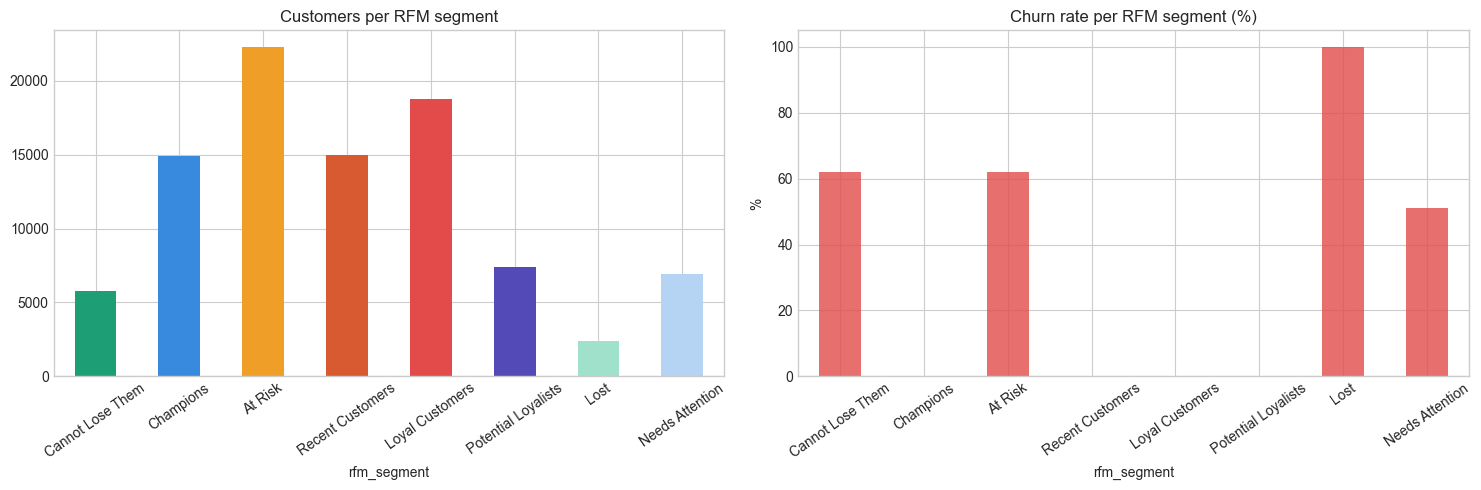

In [4]:
os.chdir(r"C:\Users\dell\OneDrive\Desktop\ecommerce_intelligence")


seg_stats = df.groupby('rfm_segment').agg(
    customers =('customer_unique_id','count'),
    avg_monetary =('monetary','mean'),
    avg_recency =('recency_days','mean'),
    churn_rate =(CHURN_TARGET,'mean')
).round(2).sort_values('avg_monetary', ascending=False)
seg_stats['pct_customers'] = (seg_stats['customers'] /
seg_stats['customers'].sum() * 100).round(1)
print(seg_stats.to_string())
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors =     ['#1D9E75','#378ADD','#EF9F27','#D85A30','#E24B4A','#534AB7','#9FE1CB'
,'#B5D4F4']

seg_stats['customers'].plot(kind='bar', ax=axes[0],
 color=colors[:len(seg_stats)], edgecolor='none')
axes[0].set_title('Customers per RFM segment')
axes[0].tick_params(axis='x', rotation=35)
(seg_stats['churn_rate'] * 100).plot(kind='bar', ax=axes[1],
 color='#E24B4A', alpha=0.8,
edgecolor='none')
axes[1].set_title('Churn rate per RFM segment (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('docs/screenshots/07_rfm_churn_rates.png', dpi=100,
bbox_inches = 'tight')
plt.show()

## Step 4 — Train Churn Model

This cell calls `src\train_churn.py` which:
* Applies SMOTE to fix class imbalance
* Trains XGBoost with early stopping
* Logs all metrics + SHAP plots to MLflow at http://localhost:5000
* Writes predictions to ml_churn_predictions table in PostgreSQL

**Make sure MLflow is running first:**

In [7]:
# mlflow ui --port 5000
import os
# Move working directory to project root
# os.chdir("..")   # from notebooks/01_eda → notebooks
# os.chdir("..")   # from notebooks → project root

print("Current working dir:", os.getcwd())
from src.train_churn import train_churn_model
model = train_churn_model()
print('\nTraining complete. Open http://localhost:5000 to see experiment logs.')


Current working dir: C:\Users\dell\OneDrive\Desktop\ecommerce_intelligence
CHURN MODEL TRAINING

[1/5] Building feature matrix ...
Pulling RFM features ...
Pulling review features ...
Pulling category features ...
Feature matrix: 93,357 customers | churn rate 24.9%
[2/5] Applying SMOTE ...
Train samples after SMOTE: 112,178
[3/5] Training XGBoost ...
[4/5] Evaluating ...

      AUC     : 1.0000
      CV AUC  : 1.0000 ± 0.0000

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00     14023
     Churned       1.00      1.00      1.00      4649

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672

      Computing SHAP values ...


Registered model 'ecommerce_churn' already exists. Creating a new version of this model...
2026/04/09 20:52:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ecommerce_churn, version 7
Created version '7' of model 'ecommerce_churn'.


[5/5] Writing predictions to PostgreSQL ...
      93,357 rows → ml_churn_predictions

Done. Open http://localhost:5000 to see MLflow logs.

Training complete. Open http://localhost:5000 to see experiment logs.


## Step 5 — SHAP feature importance (interactive plot)


In [10]:
import os
# # Move working directory to project root
# os.chdir("..")   # from notebooks/01_eda → notebooks
# os.chdir("..")   # from notebooks → project root
print("Current working dir:", os.getcwd())

X = df[FEATURE_COLS]
y = df[CHURN_TARGET]
_, X_test, _, _ = train_test_split(X, y, test_size=0.2,
random_state=42, stratify=y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
# Beeswarm — shows direction AND magnitude of each feature's effect
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS,
show=False, max_display=13)
plt.title('SHAP — Feature impact on churn probability')
plt.tight_layout()
plt.savefig('docs/screenshots/08_shap_beeswarm.png', dpi=100,
bbox_inches='tight')

plt.show()

Current working dir: C:\Users\dell\OneDrive\Desktop\ecommerce_intelligence


In [11]:
from sqlalchemy import text

preds = pd.read_sql("""
    SELECT
        rfm_segment,
        churn_label,
        COUNT(*)                                      AS customers,
        ROUND(AVG(churn_probability)::NUMERIC, 4)     AS avg_churn_prob,
        ROUND(AVG(monetary)::NUMERIC, 2)              AS avg_monetary
    FROM ml_churn_predictions
    GROUP BY rfm_segment, churn_label
    ORDER BY rfm_segment, churn_label
""", engine)

print('Predictions in ml_churn_predictions table:')
print(preds.to_string(index=False))
print(f'\nTotal rows: {preds["customers"].sum():,}')
print('\nNext step: Open notebooks\\03_clv\\lightgbm_clv.ipynb')

Predictions in ml_churn_predictions table:
        rfm_segment churn_label  customers  avg_churn_prob  avg_monetary
            At Risk      Medium      22300          0.5286        167.04
   Cannot Lose Them      Medium       5747          0.5273        308.50
          Champions      Medium      14918          0.3648        176.92
               Lost      Medium       2385          0.6290         73.08
    Loyal Customers      Medium      18796          0.3648        161.29
    Needs Attention      Medium       6894          0.4998         72.57
Potential Loyalists      Medium       7356          0.3648        154.16
   Recent Customers      Medium      14961          0.3650        163.41

Total rows: 93,357

Next step: Open notebooks\03_clv\lightgbm_clv.ipynb
